# SSM Knowledge Distillation Analysis
Analyzing the effect of KD hyperparameters (temperature, alpha) on accuracy and robustness.

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

PROJECT_DIR = Path(".")
plt.style.use("seaborn-v0_8-whitegrid")

## 1. Load distillation results

In [12]:
df_distill = pd.read_csv(PROJECT_DIR / "distillation_results.csv")
print("Distillation results shape:", df_distill.shape)
df_distill

Distillation results shape: (24, 5)


,temperature,alpha,seed,best_acc,best_f1
0,1,0.0,42,0.8810,0.8700
1,1,0.0,123,0.8740,0.8634
2,1,0.5,42,0.8916,0.8827
3,1,0.5,123,0.8714,0.8604
4,1,1.0,42,0.8461,0.8324
5,1,1.0,123,0.8857,0.8769
6,2,0.0,42,0.8359,0.8227
7,2,0.0,123,0.8645,0.8535
8,2,0.5,42,0.8848,0.8761
9,2,0.5,123,0.8718,0.8611


## 2. Distillation accuracy heatmaps

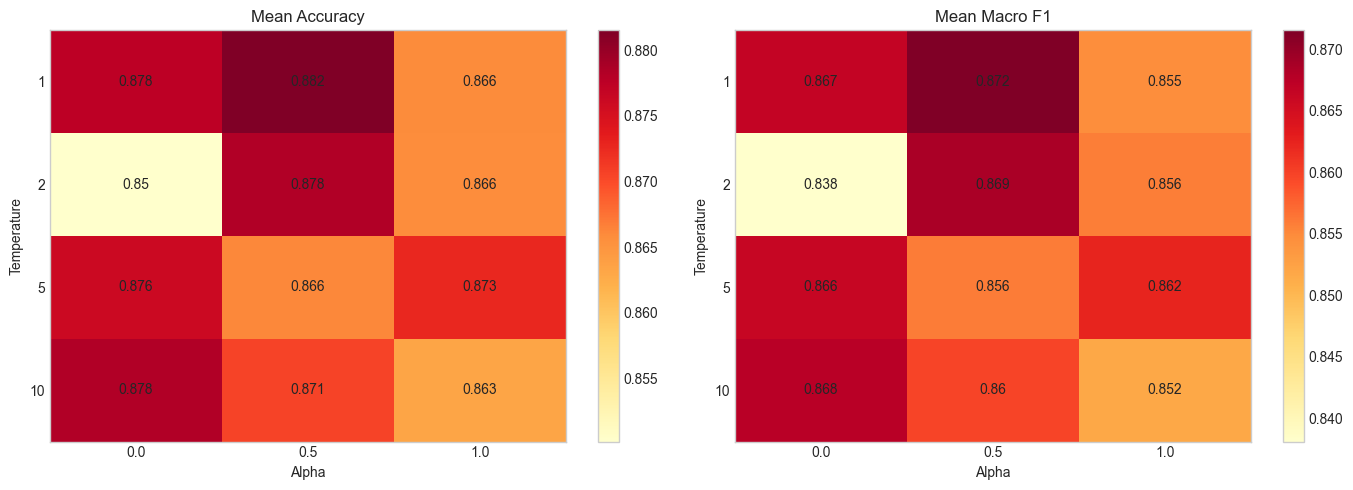

In [13]:
#average over seeds
df_mean = df_distill.groupby(["temperature", "alpha"]).agg(
    mean_acc=("best_acc", "mean"),
    std_acc=("best_acc", "std"),
    mean_f1=("best_f1", "mean"),
    std_f1=("best_f1", "std"),
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, title in zip(axes, ["mean_acc", "mean_f1"], ["Mean Accuracy", "Mean Macro F1"]):
    pivot = df_mean.pivot(index="temperature", columns="alpha", values=metric)
    im = ax.imshow(pivot.values, cmap="YlOrRd", aspect="auto")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_xlabel("Alpha")
    ax.set_ylabel("Temperature")
    ax.set_title(title)
    ax.grid(False)
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            ax.text(j, i, str(round(pivot.values[i, j], 3)),
                    ha="center", va="center", fontsize=10)
    fig.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

## 3. Accuracy vs alpha (line plot per temperature)

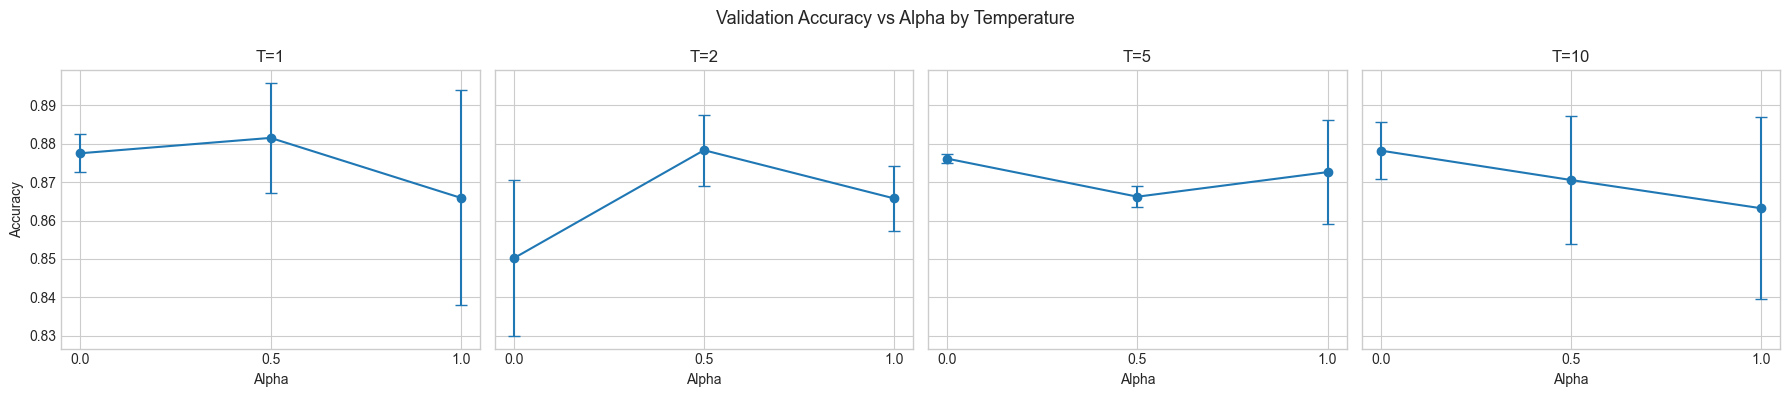

In [14]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)

for ax, temp in zip(axes, sorted(df_mean["temperature"].unique())):
    subset = df_mean[df_mean["temperature"] == temp]
    ax.errorbar(subset["alpha"], subset["mean_acc"], yerr=subset["std_acc"],
                marker="o", capsize=4, color="tab:blue")
    ax.set_xlabel("Alpha")
    ax.set_title("T=" + str(temp))
    ax.set_xticks(subset["alpha"].values)

axes[0].set_ylabel("Accuracy")
fig.suptitle("Validation Accuracy vs Alpha by Temperature", fontsize=13)
plt.tight_layout()
plt.show()

## 4. Load robustness results (large student, small student if available)

In [15]:
df_robust = pd.read_csv(PROJECT_DIR / "robustness_results.csv")
print("Large student robustness shape:", df_robust.shape)

small_rob_path = PROJECT_DIR / "robustness_results_small_student.csv"
has_small_robust = small_rob_path.exists()
if has_small_robust:
    df_robust_small = pd.read_csv(small_rob_path)
    print("Small student robustness shape:", df_robust_small.shape)
else:
    print("Small student robustness not found, skipping small student plots")

df_robust

Large student robustness shape: (24, 23)
Small student robustness shape: (24, 23)


,temperature,alpha,seed,clean_acc,clean_f1,fgsm_0.01_acc,fgsm_0.01_f1,fgsm_0.05_acc,fgsm_0.05_f1,fgsm_0.1_acc,...,noise_10db_acc,noise_10db_f1,noise_5db_acc,noise_5db_f1,trunc_25_acc,trunc_25_f1,trunc_50_acc,trunc_50_f1,trunc_75_acc,trunc_75_f1
0,1,0.0,42,0.8698,0.8594,0.6652,0.6826,0.6554,0.6948,0.6536,...,0.6283,0.6143,0.4730,0.4491,0.8021,0.7914,0.5009,0.5016,0.1448,0.1459
1,1,0.0,123,0.8582,0.8497,0.6759,0.6931,0.6652,0.7030,0.6587,...,0.6247,0.6030,0.4728,0.4261,0.7854,0.7747,0.4910,0.4878,0.1403,0.1471
2,1,0.5,42,0.8760,0.8664,0.6798,0.6865,0.6733,0.7253,0.6708,...,0.6135,0.5848,0.4283,0.3896,0.8021,0.7914,0.5081,0.5116,0.1434,0.1449
3,1,0.5,123,0.8607,0.8515,0.6662,0.6871,0.6566,0.7192,0.6539,...,0.6131,0.5990,0.4319,0.3953,0.7892,0.7791,0.4871,0.4839,0.1359,0.1349
4,1,1.0,42,0.8263,0.8159,0.5610,0.5878,0.5479,0.6067,0.5500,...,0.4827,0.4677,0.2995,0.2863,0.7500,0.7407,0.4583,0.4580,0.1307,0.1291
5,1,1.0,123,0.8662,0.8567,0.6894,0.7152,0.6780,0.7364,0.6767,...,0.5997,0.5838,0.4245,0.3891,0.7968,0.7888,0.4947,0.4933,0.1399,0.1389
6,2,0.0,42,0.8194,0.8083,0.5428,0.5647,0.5337,0.5961,0.5300,...,0.5403,0.5339,0.4229,0.4080,0.7442,0.7334,0.4476,0.4514,0.1239,0.1214
7,2,0.0,123,0.8498,0.8400,0.6399,0.6403,0.6169,0.6880,0.6146,...,0.5997,0.5879,0.4635,0.4492,0.7715,0.7595,0.4765,0.4763,0.1343,0.1394
8,2,0.5,42,0.8708,0.8616,0.7630,0.7659,0.7604,0.7908,0.7601,...,0.5463,0.5468,0.3745,0.3603,0.7989,0.7891,0.5009,0.5043,0.1477,0.1494
9,2,0.5,123,0.8560,0.8462,0.7517,0.7662,0.7453,0.8061,0.7444,...,0.6322,0.6149,0.4590,0.4228,0.7789,0.7671,0.4812,0.4762,0.1338,0.1395


## 5. Robustness: FGSM attack (large student, small student if available)

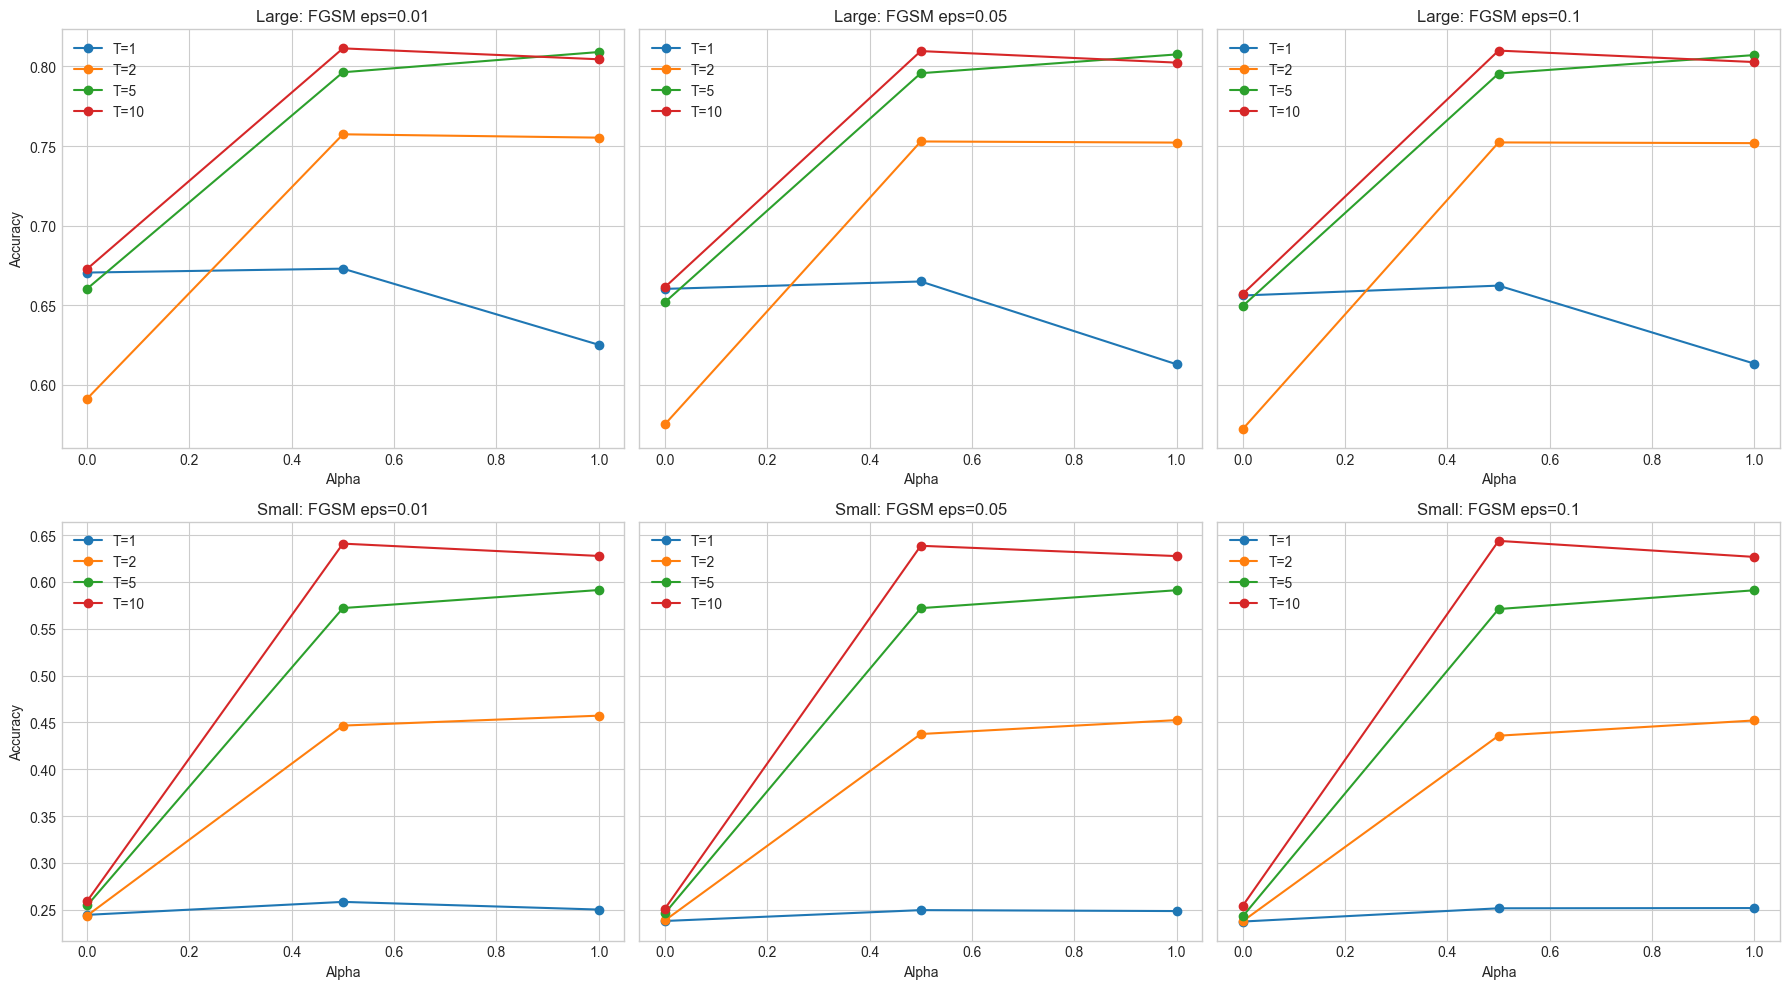

In [16]:
df_rob_mean = df_robust.groupby(["temperature", "alpha"]).mean(numeric_only=True).reset_index()

n_rows = 2 if has_small_robust else 1
fig, axes = plt.subplots(n_rows, 3, figsize=(18, 5 * n_rows), sharey="row")
if n_rows == 1:
    axes = [axes]

for ax, eps in zip(axes[0], [0.01, 0.05, 0.1]):
    for temp in sorted(df_rob_mean["temperature"].unique()):
        subset = df_rob_mean[df_rob_mean["temperature"] == temp]
        ax.plot(subset["alpha"], subset["fgsm_" + str(eps) + "_acc"], marker="o", label="T=" + str(temp))
    ax.set_xlabel("Alpha")
    ax.set_title("Large: FGSM eps=" + str(eps))
    ax.legend()
axes[0][0].set_ylabel("Accuracy")

if has_small_robust:
    df_rob_small_mean = df_robust_small.groupby(["temperature", "alpha"]).mean(numeric_only=True).reset_index()
    for ax, eps in zip(axes[1], [0.01, 0.05, 0.1]):
        for temp in sorted(df_rob_small_mean["temperature"].unique()):
            subset = df_rob_small_mean[df_rob_small_mean["temperature"] == temp]
            ax.plot(subset["alpha"], subset["fgsm_" + str(eps) + "_acc"], marker="o", label="T=" + str(temp))
        ax.set_xlabel("Alpha")
        ax.set_title("Small: FGSM eps=" + str(eps))
        ax.legend()
    axes[1][0].set_ylabel("Accuracy")

plt.tight_layout()
plt.show()

## 6. Robustness: Noise injection

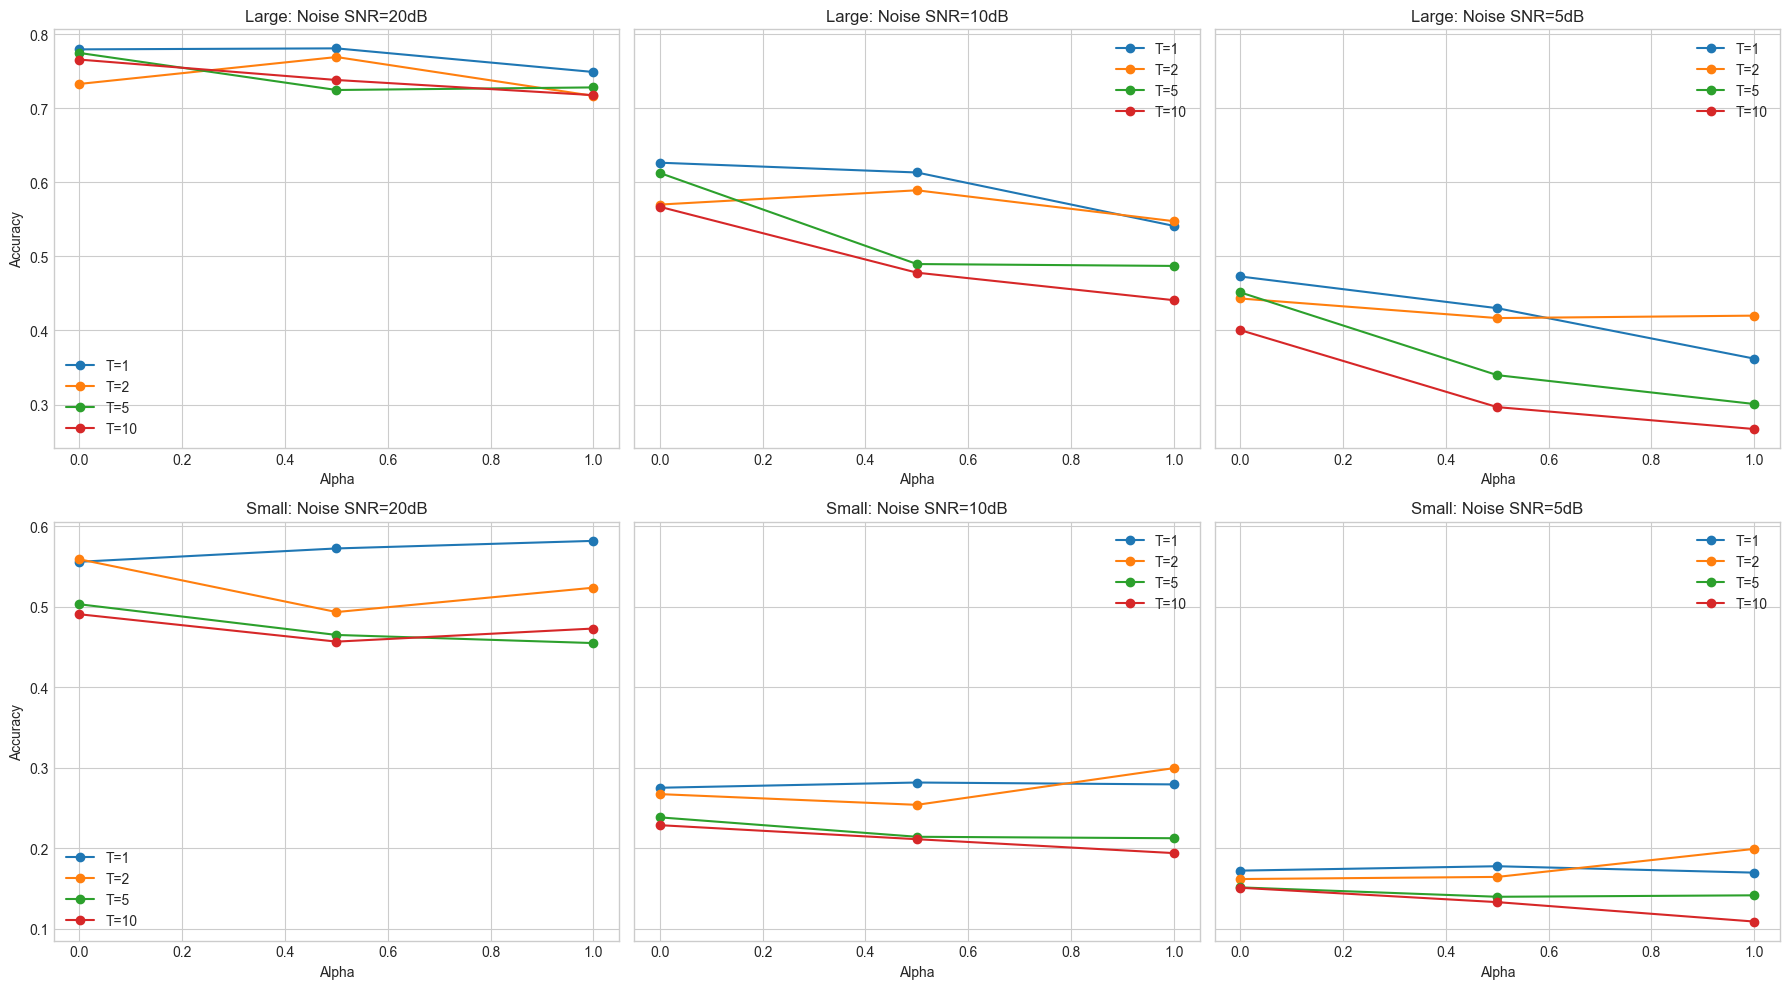

In [17]:
n_rows = 2 if has_small_robust else 1
fig, axes = plt.subplots(n_rows, 3, figsize=(18, 5 * n_rows), sharey="row")
if n_rows == 1:
    axes = [axes]

for ax, snr in zip(axes[0], [20, 10, 5]):
    for temp in sorted(df_rob_mean["temperature"].unique()):
        subset = df_rob_mean[df_rob_mean["temperature"] == temp]
        ax.plot(subset["alpha"], subset["noise_" + str(snr) + "db_acc"], marker="o", label="T=" + str(temp))
    ax.set_xlabel("Alpha")
    ax.set_title("Large: Noise SNR=" + str(snr) + "dB")
    ax.legend()
axes[0][0].set_ylabel("Accuracy")

if has_small_robust:
    for ax, snr in zip(axes[1], [20, 10, 5]):
        for temp in sorted(df_rob_small_mean["temperature"].unique()):
            subset = df_rob_small_mean[df_rob_small_mean["temperature"] == temp]
            ax.plot(subset["alpha"], subset["noise_" + str(snr) + "db_acc"], marker="o", label="T=" + str(temp))
        ax.set_xlabel("Alpha")
        ax.set_title("Small: Noise SNR=" + str(snr) + "dB")
        ax.legend()
    axes[1][0].set_ylabel("Accuracy")

plt.tight_layout()
plt.show()

## 7. Robustness: Sequence truncation

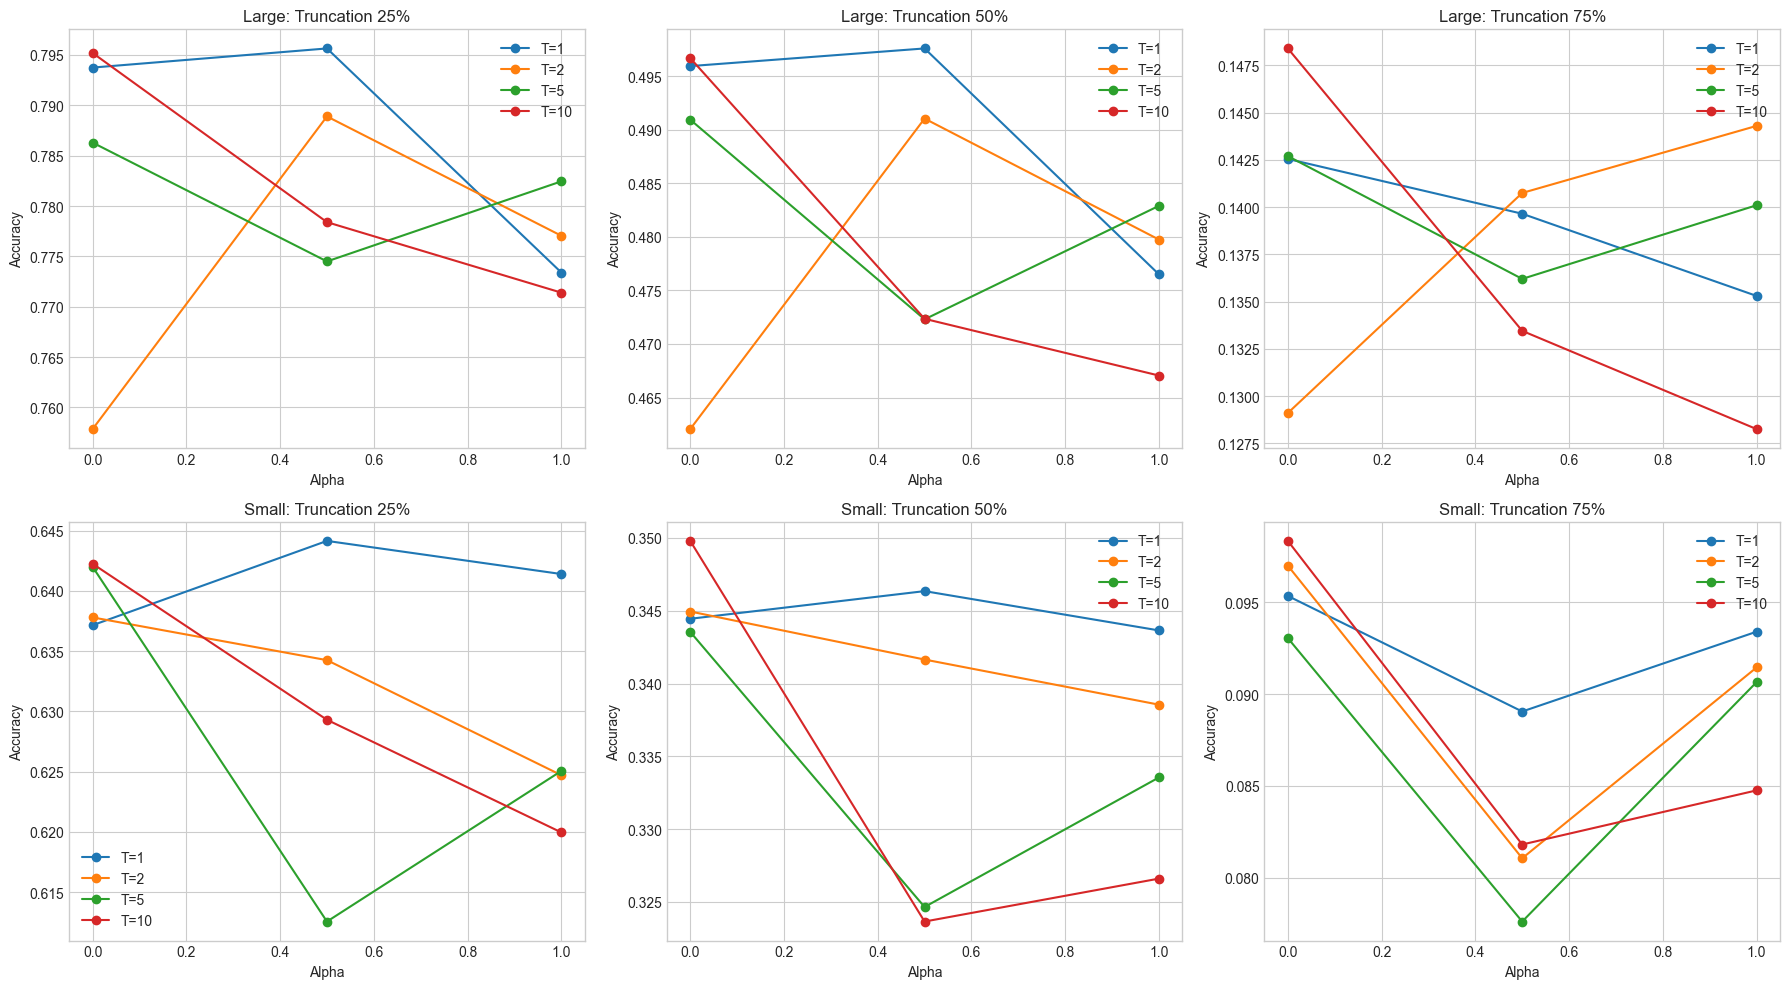

In [18]:
n_rows = 2 if has_small_robust else 1
fig, axes = plt.subplots(n_rows, 3, figsize=(18, 5 * n_rows))
if n_rows == 1:
    axes = [axes]

for ax, pct in zip(axes[0], [25, 50, 75]):
    for temp in sorted(df_rob_mean["temperature"].unique()):
        subset = df_rob_mean[df_rob_mean["temperature"] == temp]
        ax.plot(subset["alpha"], subset["trunc_" + str(pct) + "_acc"], marker="o", label="T=" + str(temp))
    ax.set_xlabel("Alpha")
    ax.set_ylabel("Accuracy")
    ax.set_title("Large: Truncation " + str(pct) + "%")
    ax.legend()

if has_small_robust:
    for ax, pct in zip(axes[1], [25, 50, 75]):
        for temp in sorted(df_rob_small_mean["temperature"].unique()):
            subset = df_rob_small_mean[df_rob_small_mean["temperature"] == temp]
            ax.plot(subset["alpha"], subset["trunc_" + str(pct) + "_acc"], marker="o", label="T=" + str(temp))
        ax.set_xlabel("Alpha")
        ax.set_ylabel("Accuracy")
        ax.set_title("Small: Truncation " + str(pct) + "%")
        ax.legend()

plt.tight_layout()
plt.show()

## 8. Robustness heatmaps (aggregated)

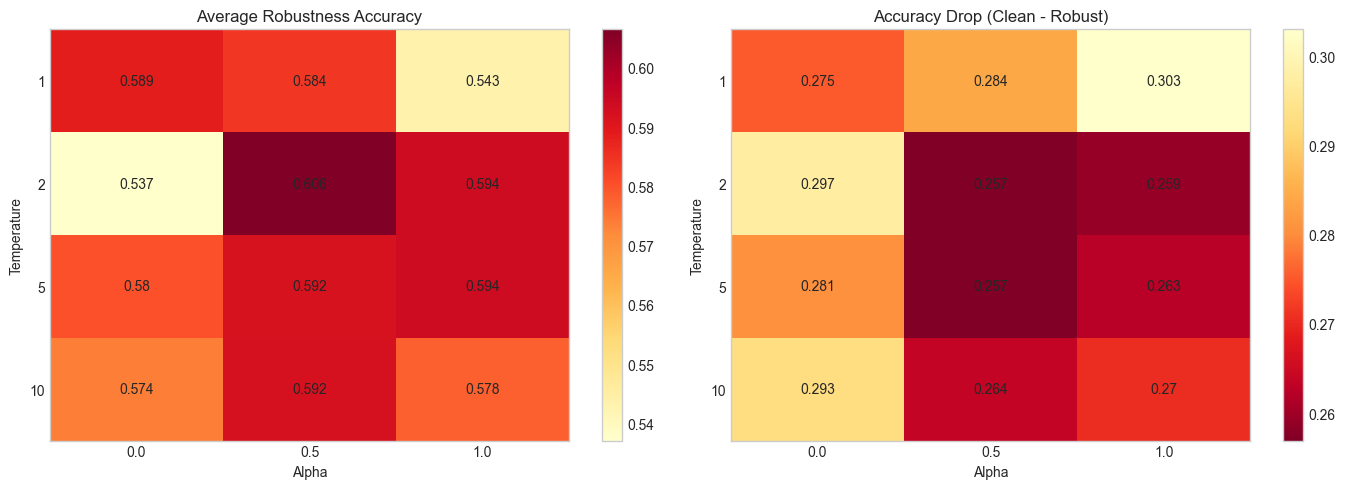

In [19]:
#compute average robustness score across all attack types
attack_cols = [
    "fgsm_0.01_acc", "fgsm_0.05_acc", "fgsm_0.1_acc",
    "noise_20db_acc", "noise_10db_acc", "noise_5db_acc",
    "trunc_25_acc", "trunc_50_acc", "trunc_75_acc",
]
df_rob_mean["avg_robust_acc"] = df_rob_mean[attack_cols].mean(axis=1)

#also compute accuracy drop from clean
df_rob_mean["acc_drop"] = df_rob_mean["clean_acc"] - df_rob_mean["avg_robust_acc"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, title, cmap in zip(
    axes,
    ["avg_robust_acc", "acc_drop"],
    ["Average Robustness Accuracy", "Accuracy Drop (Clean - Robust)"],
    ["YlOrRd", "YlOrRd_r"]
):
    pivot = df_rob_mean.pivot(index="temperature", columns="alpha", values=metric)
    im = ax.imshow(pivot.values, cmap=cmap, aspect="auto")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_xlabel("Alpha")
    ax.set_ylabel("Temperature")
    ax.set_title(title)
    ax.grid(False)
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            ax.text(j, i, str(round(pivot.values[i, j], 3)),
                    ha="center", va="center", fontsize=10)
    fig.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

## 9. Summary comparison: small vs large student

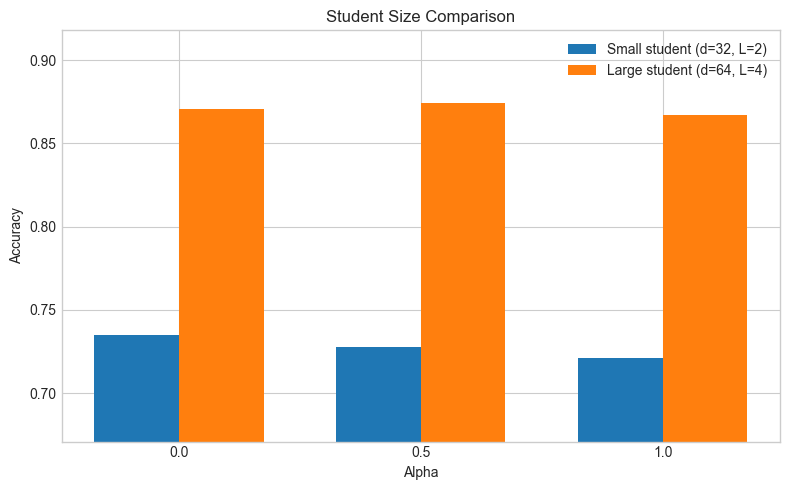

In [20]:
#load small student results if available
small_path = PROJECT_DIR / "distillation_results_small_student.csv"
if small_path.exists():
    df_small = pd.read_csv(small_path)
    df_small_mean = df_small.groupby(["temperature", "alpha"]).agg(
        mean_acc=("best_acc", "mean")).reset_index()
    df_large_mean = df_distill.groupby(["temperature", "alpha"]).agg(
        mean_acc=("best_acc", "mean")).reset_index()

    fig, ax = plt.subplots(figsize=(8, 5))
    alphas = sorted(df_small_mean["alpha"].unique())
    x = np.arange(len(alphas))
    width = 0.35

    #average over temperatures for simplicity
    small_accs = [df_small_mean[df_small_mean["alpha"] == a]["mean_acc"].mean() for a in alphas]
    large_accs = [df_large_mean[df_large_mean["alpha"] == a]["mean_acc"].mean() for a in alphas]

    ax.bar(x - width/2, small_accs, width, label="Small student (d=32, L=2)")
    ax.bar(x + width/2, large_accs, width, label="Large student (d=64, L=4)")
    ax.set_xticks(x)
    ax.set_xticklabels(alphas)
    ax.set_xlabel("Alpha")
    ax.set_ylabel("Accuracy")
    ax.set_title("Student Size Comparison")
    ax.set_ylim(bottom=max(0, min(min(small_accs), min(large_accs)) - 0.05))
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Small student results not found, skipping comparison.")